# 🏭 Industrial Defect Detection with Transfer Learning
### Computer Vision — End-to-End Notebook

---

| Item | Details |
|---|---|
| **Dataset** | Casting Product Defect Dataset (Kaggle) |
| **Model** | MobileNetV2 — Transfer Learning |
| **Task** | Binary Classification: `good` vs `defective` |

---




## 1. Business Problem

### The real-world scenario
A factory manufactures metal casting parts (impellers, rotors, etc.).  
Some parts come out with surface defects — **pits, scratches, misalignment, incomplete filling**.

**Current process:** A human inspector looks at each part → slow, expensive, inconsistent.

**Goal:** Train a model that inspects part images in real-time and flags defectives.

### Why this matters in industry
| Challenge | Detail |
|---|---|
| Scale | 1000s of parts/hour → no human can keep up |
| Consistency | Fatigue causes missed defects on late shifts |
| Cost | Defective parts shipped to customers = warranty claims |
| Speed | Model inference < 10ms → production line can't wait |

### What makes a good industrial ML model?
- **High Recall** → don't miss real defects (costly!)  
- **Acceptable Precision** → don't halt the line on false alarms  
- **Explainable** → engineers need to *trust* the decision  
- **Fast** → runs at production speed  
- **Robust** → handles slight variations in lighting, camera angle


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 1: Install required packages
# ─────────────────────────────────────────────────────────────────────────
import subprocess, sys

packages = [
    "tensorflow",         # Deep learning framework
    "kagglehub",          # Kaggle dataset downloader
    "scikit-learn",       # Metrics, train/test split
    "matplotlib",         # Plots
    "seaborn",            # Better-looking confusion matrix
    "pillow",             # Image utilities
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

print("All packages installed.")


All packages installed.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 2: Import libraries
# ─────────────────────────────────────────────────────────────────────────
import os
import shutil
import pathlib
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    roc_curve,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f" TensorFlow version : {tf.__version__}")
print(f" GPU available       : {len(tf.config.list_physical_devices('GPU')) > 0}")


 TensorFlow version : 2.19.0
 GPU available       : False


## 2. Dataset: Casting Product Defect Dataset

### 📦 Which dataset to use — and why

| Property | Value |
|---|---|
| **Name** | Casting Manufacturing Product Image Data |
| **Source** | [Kaggle — ravirajsinh45](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product) |
| **Domain** | Metal casting manufacturing (submersible pump impellers) |
| **Images** | ~1300 grayscale images (512×512) |
| **Classes** | `ok_front` (good) · `def_front` (defective) |
| **Why ideal** | Real industrial images, realistic imbalance, clear defect patterns |

**Defect types visible in the dataset:**
- Surface pits and blow holes  
- Incomplete material filling  
- Shrinkage defects  
- Cold shut (premature solidification)

### Folder structure AFTER reorganization
```
data/
├── train/
│   ├── good/           ← ok_front images (80% of original train)
│   └── defective/      ← def_front images (80% of original train)
├── val/
│   ├── good/           ← ok_front images (20% of original train)
│   └── defective/      ← def_front images (20% of original train)
└── test/
    ├── good/           ← ok_front images (original test set)
    └── defective/      ← def_front images (original test set)
```

### How to get the dataset

**Option A (recommended):** Auto-download with `kagglehub` in the next cell.  
You must be logged into Kaggle. The first run will ask for your Kaggle username and API key.  
→ Get your key at: https://www.kaggle.com/settings → API → Create New Token

**Option B (manual):**
1. Download from the Kaggle URL above
2. Unzip to create a folder named `casting_512x512/` in the same directory as this notebook
3. Set `MANUAL_PATH = "casting_512x512"` in the next cell


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 3: Download dataset
# ─────────────────────────────────────────────────────────────────────────

# ── If you downloaded manually, set this path ──
MANUAL_PATH = None   # e.g. "casting_512x512" or "/path/to/casting_512x512"

RAW_DATA_PATH = None

if MANUAL_PATH and os.path.exists(MANUAL_PATH):
    RAW_DATA_PATH = MANUAL_PATH
    print(f" Using manual path: {RAW_DATA_PATH}")
else:
    try:
        import kagglehub
        print("⬇  Downloading dataset via kagglehub...")
        print("   (First run: you will be prompted for your Kaggle credentials)")
        dataset_path = kagglehub.dataset_download(
            "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
        )
        # Find the casting_512x512 folder inside the download
        candidates = glob.glob(
            os.path.join(dataset_path, "**", "casting_512x512"), recursive=True
        )
        RAW_DATA_PATH = candidates[0] if candidates else dataset_path
        print(f"Dataset ready at: {RAW_DATA_PATH}")
    except Exception as e:
        print(f" Auto-download failed: {e}")
        print()
        print("Please download manually from:")
        print("https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product")
        print("Then set MANUAL_PATH above.")

if RAW_DATA_PATH:
    # Quick sanity check
    for sub in ["train", "test"]:
        p = pathlib.Path(RAW_DATA_PATH) / sub
        if p.exists():
            for cls in p.iterdir():
                n = len(list(cls.glob("*")))
                print(f"  {sub}/{cls.name}: {n} images")


⬇  Downloading dataset via kagglehub...
   (First run: you will be prompted for your Kaggle credentials)
Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.
Dataset ready at: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 4: Reorganize raw dataset → data/train / val / test
#
# The Kaggle "casting" dataset has NO test folder — only train/.
# We carve val (15 %) and test (10 %) directly from training images.
# If a raw test/ folder IS present we use it as-is.
# ─────────────────────────────────────────────────────────────────────────

DATA_DIR      = "data"
VAL_FRACTION  = 0.15   # 15 % → val
TEST_FRACTION = 0.10   # 10 % → test

CLASS_MAP = {"ok_front": "good", "def_front": "defective"}


def _count_images(directory):
    p = pathlib.Path(directory)
    if not p.exists():
        return 0
    return sum(1 for f in p.rglob("*") if f.suffix.lower() in {".jpg",".jpeg",".png"})


def organize_casting_dataset(raw_path, output_dir,
                              val_fraction=0.15, test_fraction=0.10, seed=42):
    output_path = pathlib.Path(output_dir)

    # Only skip if ALL three splits are non-empty
    splits_ok = all(
        _count_images(output_path / split / cls) > 0
        for split in ("train", "val", "test")
        for cls in ("good", "defective")
    )
    if splits_ok:
        print(f" '{output_dir}/' already organised. Skipping.")
        return

    print(f"📁 Organising dataset into '{output_dir}/' ...")
    raw_path = pathlib.Path(raw_path)

    for raw_cls, label in CLASS_MAP.items():
        # ── Locate source folder (search recursively) ──────────────────
        src_train = raw_path / "train" / raw_cls
        if not src_train.exists():
            hits = list(raw_path.rglob(raw_cls))
            src_train = hits[0] if hits else None
        if src_train is None or not src_train.exists():
            print(f"  ⚠  Could not find '{raw_cls}', skipping.")
            continue

        all_imgs = sorted(
            list(src_train.glob("*.jpeg")) +
            list(src_train.glob("*.jpg"))  +
            list(src_train.glob("*.png"))
        )

        # ── Check for raw test folder ───────────────────────────────────
        raw_test_src = raw_path / "test" / raw_cls
        if not raw_test_src.exists():
            hits = list(raw_path.rglob("test/" + raw_cls))
            raw_test_src = hits[0] if hits else None

        if raw_test_src and raw_test_src.exists() and _count_images(raw_test_src) > 0:
            # Raw test available — only carve val from train
            test_imgs = sorted(
                list(raw_test_src.glob("*.jpeg")) +
                list(raw_test_src.glob("*.jpg"))  +
                list(raw_test_src.glob("*.png"))
            )
            train_imgs, val_imgs = train_test_split(
                all_imgs, test_size=val_fraction, random_state=seed, shuffle=True
            )
            print(f"  ℹ  Using raw test folder for '{label}'")
        else:
            # No raw test — carve test THEN val from what remains
            remaining, test_imgs = train_test_split(
                all_imgs, test_size=test_fraction, random_state=seed, shuffle=True
            )
            adj_val = val_fraction / (1.0 - test_fraction)
            train_imgs, val_imgs = train_test_split(
                remaining, test_size=adj_val, random_state=seed, shuffle=True
            )
            print(f"  ℹ  No raw test folder — carved {len(test_imgs)} test images for '{label}'")

        for subset, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            dst = output_path / subset / label
            dst.mkdir(parents=True, exist_ok=True)
            for img in imgs:
                shutil.copy2(img, dst / img.name)

    # ── Summary ──────────────────────────────────────────────────────────
    print("\n📊 Final dataset split:")
    print(f"  {'Split':<8} {'good':>7} {'defective':>12} {'total':>8}")
    print("  " + "─" * 38)
    for split in ["train", "val", "test"]:
        n_good = _count_images(output_path / split / "good")
        n_def  = _count_images(output_path / split / "defective")
        print(f"  {split:<8} {n_good:>7} {n_def:>12} {n_good+n_def:>8}")
    print()


organize_casting_dataset(RAW_DATA_PATH, DATA_DIR,
                         val_fraction=VAL_FRACTION,
                         test_fraction=TEST_FRACTION)


📁 Organising dataset into 'data/' ...
  ℹ  No raw test folder — carved 52 test images for 'good'
  ℹ  No raw test folder — carved 79 test images for 'defective'

📊 Final dataset split:
  Split       good    defective    total
  ──────────────────────────────────────
  train        389          585      974
  val           78          117      195
  test          52           79      131



In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 5: Global configuration
# ─────────────────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)   # MobileNetV2 default — do not change
BATCH_SIZE  = 32           # 16 if you run out of GPU memory
EPOCHS_PHASE1 = 9    # Head-only training (frozen backbone)
EPOCHS_PHASE2 = 11   # Fine-tuning (top backbone unfrozen) — total budget = 20
TOTAL_EPOCHS  = EPOCHS_PHASE1 + EPOCHS_PHASE2   # 20
LR_HEAD     = 1e-3         # Learning rate while backbone is frozen
LR_FINETUNE = 1e-5         # Lower LR for fine-tuning (avoid catastrophic forgetting)

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# CLASS INDICES (alphabetical order from Keras):
#   defective → 0
#   good      → 1
# So model output (sigmoid) ≈ P(good).
# Threshold ≥ 0.5 → predicted "good"
# Threshold <  0.5 → predicted "defective"

print("Configuration:")
print(f"  IMG_SIZE   : {IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  TOTAL_EPOCHS     : {TOTAL_EPOCHS}")
print(f"  TRAIN_DIR  : {TRAIN_DIR}")
print(f"  VAL_DIR    : {VAL_DIR}")
print(f"  TEST_DIR   : {TEST_DIR}")


Configuration:
  IMG_SIZE   : (224, 224)
  BATCH_SIZE : 32
  TOTAL_EPOCHS     : 20
  TRAIN_DIR  : data/train
  VAL_DIR    : data/val
  TEST_DIR   : data/test


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 6: Load image datasets with Keras
# ─────────────────────────────────────────────────────────────────────────

def _ensure_test_split(test_dir, train_dir, fraction=0.10, seed=42):
    """
    If data/test is empty or missing, carve `fraction` of each class
    from data/train into data/test. Removes those files from train
    so they never appear in both splits.
    """
    test_path  = pathlib.Path(test_dir)
    train_path = pathlib.Path(train_dir)

    for cls_dir in sorted(train_path.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = test_path / cls_dir.name
        existing = list(out_cls.glob("*")) if out_cls.exists() else []
        if len(existing) > 0:
            continue   # already has images for this class

        all_imgs = sorted(
            list(cls_dir.glob("*.jpg"))  +
            list(cls_dir.glob("*.jpeg")) +
            list(cls_dir.glob("*.png"))
        )
        n_take = max(1, int(len(all_imgs) * fraction))
        rng    = np.random.default_rng(seed)
        chosen = rng.choice(len(all_imgs), n_take, replace=False)

        out_cls.mkdir(parents=True, exist_ok=True)
        for idx in chosen:
            src = all_imgs[idx]
            shutil.move(str(src), out_cls / src.name)   # move → removes from train

        print(f"  ✂  Moved {n_take} '{cls_dir.name}' images → test/")

    total_test = sum(1 for _ in test_path.rglob("*")
                     if _.suffix.lower() in {".jpg",".jpeg",".png"})
    print(f"Test split ready: {total_test} images in {test_dir}")


# ── Guard: create test split if needed ─────────────────────────────────
_test_count = sum(
    1 for _ in pathlib.Path(TEST_DIR).rglob("*")
    if _.suffix.lower() in {".jpg",".jpeg",".png"}
) if pathlib.Path(TEST_DIR).exists() else 0

if _test_count == 0:
    print("⚠  data/test is empty or missing. Carving test split from train …")
    _ensure_test_split(TEST_DIR, TRAIN_DIR, fraction=0.10, seed=SEED)
else:
    print(f"ℹ  data/test already has {_test_count} images — skipping carve.")

print()

# ── Load all three splits ───────────────────────────────────────────────
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=True, seed=SEED, label_mode="binary",
)
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode="binary",
)
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode="binary",
)

CLASS_NAMES = train_ds.class_names   # ['defective', 'good']
print(f"\nClass names (by index): {CLASS_NAMES}")
print(f"  Index 0 = '{CLASS_NAMES[0]}'  (label=0)")
print(f"  Index 1 = '{CLASS_NAMES[1]}'  (label=1)")
print()
print("Datasets loaded successfully.")


ℹ  data/test already has 131 images — skipping carve.

Found 974 files belonging to 2 classes.
Found 195 files belonging to 2 classes.
Found 131 files belonging to 2 classes.

Class names (by index): ['defective', 'good']
  Index 0 = 'defective'  (label=0)
  Index 1 = 'good'  (label=1)

Datasets loaded successfully.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 7: Performance optimization — prefetch
#
# .prefetch() loads the next batch while the GPU is training on the current
# batch. This prevents the GPU from waiting for disk I/O.
# ─────────────────────────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)   # test: no cache needed

print(" Prefetch applied.")


 Prefetch applied.


/tmp/ipykernel_275/3713651235.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.4)
/tmp/ipykernel_275/3713651235.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.4)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


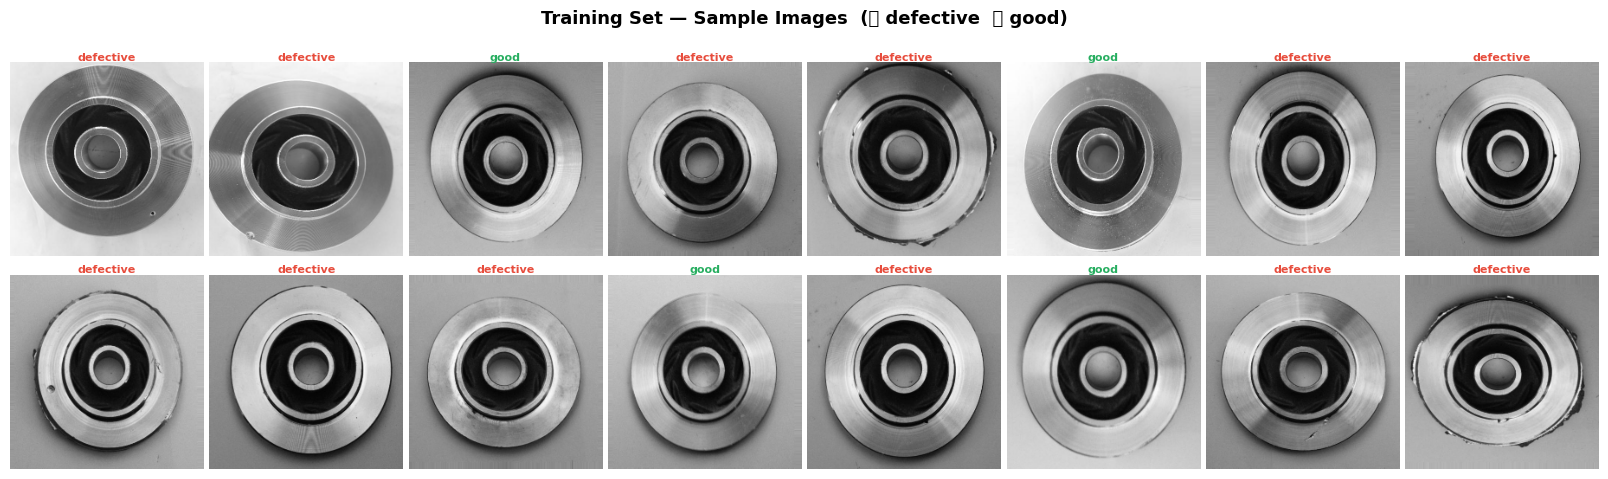

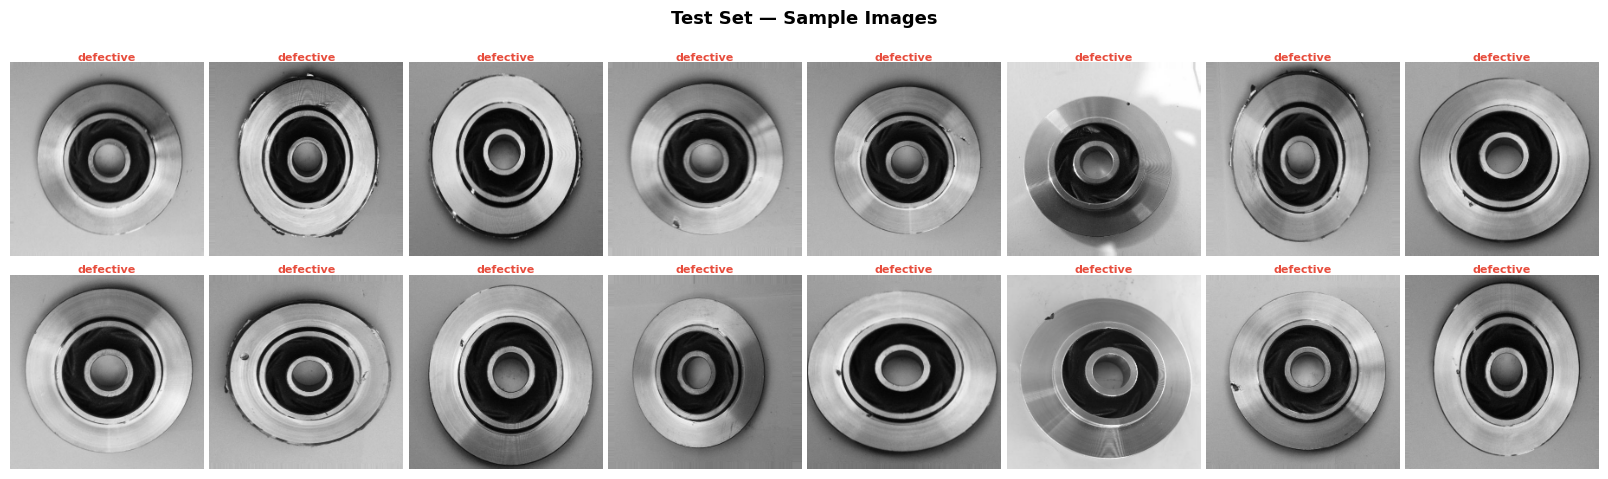

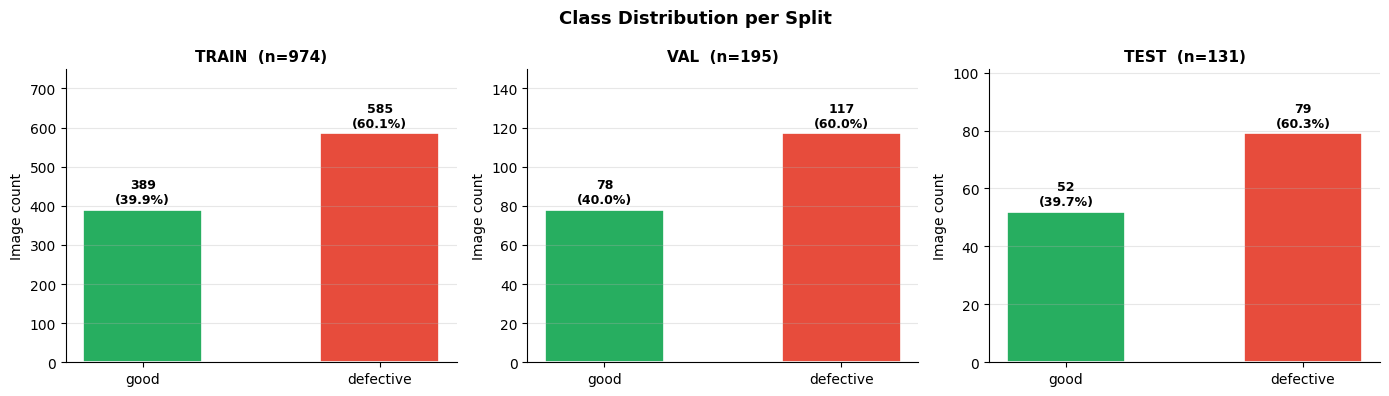


📊 Class distribution:
  Split       good    defective    total   %defective
  ────────────────────────────────────────────────────
  train        389          585      974        60.1%
  val           78          117      195        60.0%
  test          52           79      131        60.3%

⏳ Computing brightness statistics …


/tmp/ipykernel_275/3713651235.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([brightness[c] for c in CLASS_NAMES], labels=CLASS_NAMES,


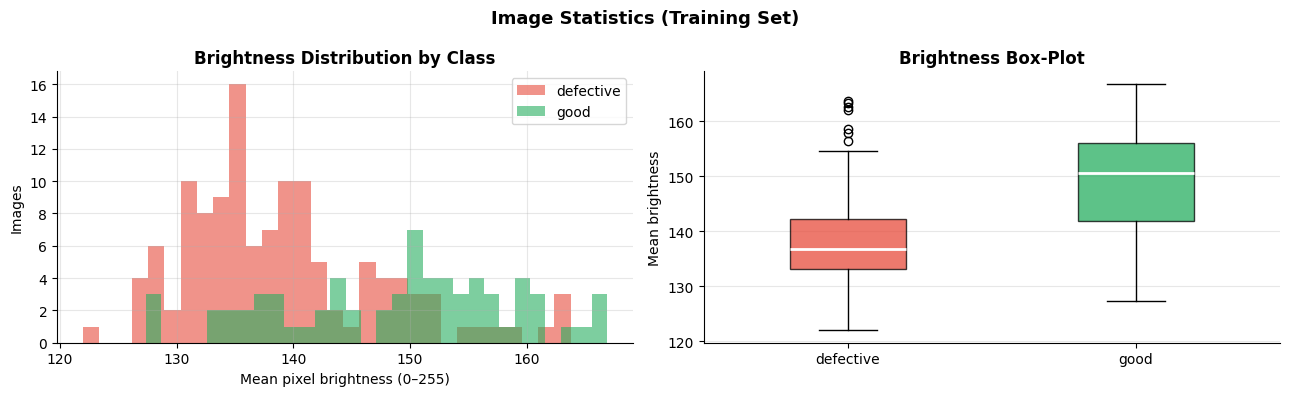

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 8a: Sample image grids — train & test
# ─────────────────────────────────────────────────────────────────────────

def show_sample_grid(ds, title, n=16, cols=8):
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
    axes = axes.flatten()
    count = 0
    for images, labels in ds.take(4):
        for img, lbl in zip(images, labels):
            if count >= n: break
            ax = axes[count]
            ax.imshow(img.numpy().astype("uint8"), cmap="gray")
            name  = CLASS_NAMES[int(lbl)]
            color = "#e74c3c" if name == "defective" else "#27ae60"
            ax.set_title(name, fontsize=8, color=color, fontweight="bold", pad=2)
            ax.axis("off")
            count += 1
        if count >= n: break
    for ax in axes[count:]: ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(pad=0.4)
    plt.show()

show_sample_grid(train_ds, "Training Set — Sample Images  (🔴 defective  🟢 good)")
show_sample_grid(test_ds,  "Test Set — Sample Images")

# ─────────────────────────────────────────────────────────────────────────
# STEP 8b: Class distribution bar charts per split
# ─────────────────────────────────────────────────────────────────────────

split_stats = {}
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    lbl_all = np.concatenate([l.numpy() for _, l in ds]).astype(int)
    n_good  = int(np.sum(lbl_all))
    n_def   = len(lbl_all) - n_good
    split_stats[name] = {"good": n_good, "defective": n_def, "total": len(lbl_all)}

palette = {"good": "#27ae60", "defective": "#e74c3c"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split, s) in zip(axes, split_stats.items()):
    bars = ax.bar(["good", "defective"], [s["good"], s["defective"]],
                  color=[palette["good"], palette["defective"]],
                  edgecolor="white", linewidth=1.2, width=0.5)
    for bar, cnt in zip(bars, [s["good"], s["defective"]]):
        pct = cnt / s["total"] * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + s["total"]*0.01,
                f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.set_title(f"{split.upper()}  (n={s['total']})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Image count")
    ax.set_ylim(0, max(s["good"], s["defective"]) * 1.28)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Class Distribution per Split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n📊 Class distribution:")
print(f"  {'Split':<8} {'good':>7} {'defective':>12} {'total':>8} {'%defective':>12}")
print("  " + "─"*52)
for split, s in split_stats.items():
    pct = s["defective"]/s["total"]*100
    print(f"  {split:<8} {s['good']:>7} {s['defective']:>12} {s['total']:>8} {pct:>11.1f}%")

# ─────────────────────────────────────────────────────────────────────────
# STEP 8c: Pixel brightness distribution per class
# ─────────────────────────────────────────────────────────────────────────

print("\n⏳ Computing brightness statistics …")
brightness = {"good": [], "defective": []}
for images, labels in train_ds.take(6):
    for img, lbl in zip(images, labels):
        cls = CLASS_NAMES[int(lbl)]
        brightness[cls].append(float(tf.reduce_mean(img)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls in CLASS_NAMES:
    axes[0].hist(brightness[cls], bins=30, alpha=0.6,
                 color=palette[cls], label=cls, edgecolor="none")
axes[0].set_xlabel("Mean pixel brightness (0–255)"); axes[0].set_ylabel("Images")
axes[0].set_title("Brightness Distribution by Class", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].spines[["top","right"]].set_visible(False)

bp = axes[1].boxplot([brightness[c] for c in CLASS_NAMES], labels=CLASS_NAMES,
                     patch_artist=True, widths=0.4)
for patch, cls in zip(bp["boxes"], CLASS_NAMES):
    patch.set_facecolor(palette[cls]); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("white"); med.set_linewidth(2)
axes[1].set_ylabel("Mean brightness"); axes[1].set_title("Brightness Box-Plot", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3); axes[1].spines[["top","right"]].set_visible(False)
plt.suptitle("Image Statistics (Training Set)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 3. Why Transfer Learning?

### The core idea
ImageNet (1.2M images, 1000 classes) has already "taught" networks to detect:
- edges, textures, shapes → low-level features
- parts of objects (wheels, faces, handles) → mid-level features

We **borrow** this knowledge and adapt the final layer to our task (good vs defective).

### Why MobileNetV2?
| Property | MobileNetV2 | VGG16 | ResNet50 |
|---|---|---|---|
| Parameters | 3.4M | 138M | 25M |
| Inference speed | ⚡ Very fast | 🐢 Slow | Medium |
| Edge-deployable | ✅ Yes | ❌ No | ⚠️ Maybe |
| Top-5 accuracy | 90.1% | 92.7% | 92.9% |

For production on a factory line, **speed and deployability** matter more than a small accuracy gap.

### Training strategy
1. **Phase 1** — Freeze the backbone, train only the new head (fast convergence)  
2. **Phase 2** — Unfreeze top layers of the backbone, fine-tune with a very low LR

> **Industry note:** You rarely train from scratch. You start from a strong pre-trained base and adapt.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 9: Build the model
#
# Architecture:
#   Input (224x224x3)
#     → Data Augmentation (flip, rotate, brightness — training only)
#     → MobileNetV2 preprocess (scale pixels to [-1, 1])
#     → MobileNetV2 backbone (frozen)  → (7, 7, 1280) feature maps
#     → Global Average Pooling         → (1280,) vector
#     → Dropout(0.3)
#     → Dense(1, sigmoid)              → P(good)
#
# We also build gradcam_model that exposes the (7,7,1280) feature maps
# alongside the final prediction — needed for Grad-CAM visualization.
# ─────────────────────────────────────────────────────────────────────────

# ── Data augmentation ─────────────────────────────────────────────────
# Applied ONLY during training (Keras handles this automatically in .fit())
# Simulates factory variability: slight rotations, brightness changes, flips
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.05),           # ±5% rotation
    layers.RandomZoom(0.1),                # ±10% zoom
    layers.RandomBrightness(0.15),         # ±15% brightness → lighting changes
    layers.RandomContrast(0.1),            # ±10% contrast
], name="data_augmentation")

# ── MobileNetV2 backbone ──────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,     # Remove ImageNet classification head
    weights="imagenet",    # Use pretrained weights
)
base_model.trainable = False  # Freeze all backbone layers (Phase 1)
print(f"Backbone: {base_model.name}")
print(f"  Layers: {len(base_model.layers)}")
print(f"  Output shape: {base_model.output_shape}")

# ── Build functional model ────────────────────────────────────────────
inputs = keras.Input(shape=IMG_SIZE + (3,), name="input_image")

# Augmentation (active during training, pass-through during inference)
x = data_augmentation(inputs)

# Scale pixels from [0, 255] to [-1, 1] (MobileNetV2 requirement)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Extract spatial feature maps
feature_maps = base_model(x, training=False)   # training=False

# Pool over spatial maps
x = layers.GlobalAveragePooling2D(name="gap")(feature_maps)
x = layers.Dropout(0.3, name="dropout")(x)

# Binary output: P(good)
outputs = layers.Dense(1, activation="sigmoid", name="predictions")(x)

model = keras.Model(inputs, outputs, name="defect_detector")

# ── Grad-CAM twin model ───────────────────────────────────────────────
# Outputs BOTH the spatial feature maps AND the final prediction.
# Used later for explainability.
gradcam_model = keras.Model(
    inputs=model.inputs,
    outputs=[feature_maps, model.output],
    name="gradcam_model",
)
print("\n model and gradcam_model built.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone: mobilenetv2_1.00_224
  Layers: 154
  Output shape: (None, 7, 7, 1280)

 model and gradcam_model built.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 10: Compile the model
#
# Loss  : binary_crossentropy → standard for 2-class sigmoid output
# Metrics:
#   accuracy  → overall % correct (easy to understand)
#   precision → of all flagged defectives, how many are real?
#   recall    → of all real defectives, how many did we catch?
#   AUC       → area under ROC curve (threshold-independent quality score)
#
# In industry, RECALL is usually more important than precision for defects.
# ─────────────────────────────────────────────────────────────────────────

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

# Show trainable parameter count
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  (only the head — backbone is frozen)")
model.summary(line_length=80)


Total parameters    : 2,259,265
Trainable parameters: 1,281  (only the head — backbone is frozen)


Model: "defect_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ data_augmentation (Sequential)    │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ true_divide (TrueDivide)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ subtract (Subtract)               │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 1)                │         1,281 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 11: Handle class imbalance with class weights
#
# The casting dataset has more defective images than good ones.
# Class weights penalize mistakes on the minority class more heavily,
# making the model pay attention to it equally.
# ─────────────────────────────────────────────────────────────────────────

all_train_labels = np.concatenate([labels.numpy() for _, labels in train_ds])
n_total    = len(all_train_labels)
n_good     = int(np.sum(all_train_labels))       # label=1 → good
n_defective = n_total - n_good                   # label=0 → defective

# Balanced weighting formula: total / (n_classes * n_samples_in_class)
weight_defective = n_total / (2 * n_defective)
weight_good      = n_total / (2 * n_good)

class_weight = {
    0: weight_defective,   # label 0 = defective → upweight if fewer
    1: weight_good,        # label 1 = good
}

print(f"Training images  : {n_total}")
print(f"  good           : {n_good}  (label=1)")
print(f"  defective      : {n_defective}  (label=0)")
print()
print(f"Class weights    : {class_weight}")
print()
print("Interpretation: The model is penalized more heavily for misclassifying")
print("the minority class, making training balanced despite unequal image counts.")


Training images  : 974
  good           : 389  (label=1)
  defective      : 585  (label=0)

Class weights    : {0: 0.8324786324786325, 1: 1.2519280205655527}

Interpretation: The model is penalized more heavily for misclassifying
the minority class, making training balanced despite unequal image counts.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 12: Train — Phase 1 (frozen backbone)
#
# Train only the classification head for EPOCHS_PHASE1 epochs.
# EarlyStopping monitors val_recall with patience=4, so it may stop
# before the full budget if the model has already converged.
# ─────────────────────────────────────────────────────────────────────────

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall",
        patience=4,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("=" * 60)
print(f"PHASE 1: Head training  (backbone FROZEN)  — up to {EPOCHS_PHASE1} epochs")
print("=" * 60)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight,
    callbacks=callbacks_phase1,
    verbose=1,
)

n1 = len(history_phase1.history["loss"])
print(f"\n Phase 1 complete — ran {n1}/{EPOCHS_PHASE1} epochs.")


PHASE 1: Head training  (backbone FROZEN)  — up to 9 epochs
Epoch 1/9
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.6537 - auc: 0.6991 - loss: 0.6289 - precision: 0.5147 - recall: 0.5350 - val_accuracy: 0.7538 - val_auc: 0.8682 - val_loss: 0.4820 - val_precision: 0.6415 - val_recall: 0.8718 - learning_rate: 0.0010
Epoch 2/9
31/31 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7525 - auc: 0.8292 - loss: 0.5029 - precision: 0.6401 - recall: 0.7789 - val_accuracy: 0.8000 - val_auc: 0.9064 - val_loss: 0.4280 - val_precision: 0.6931 - val_recall: 0.8974 - learning_rate: 0.0010
Epoch 3/9
31/31 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7906 - auc: 0.8751 - loss: 0.4413 - precision: 0.6852 - recall: 0.8228 - val_accuracy: 0.8103 - val_auc: 0.9311 - val_loss: 0.3850 - val_precision: 0.7071 - val_recall: 0.8974 - learning_rate: 0.0010
Epoch 4/9
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8199 - auc: 0.9018 - loss: 0.3997 - precision: 0.7252 - recall: 0.8424 - val_accuracy: 0

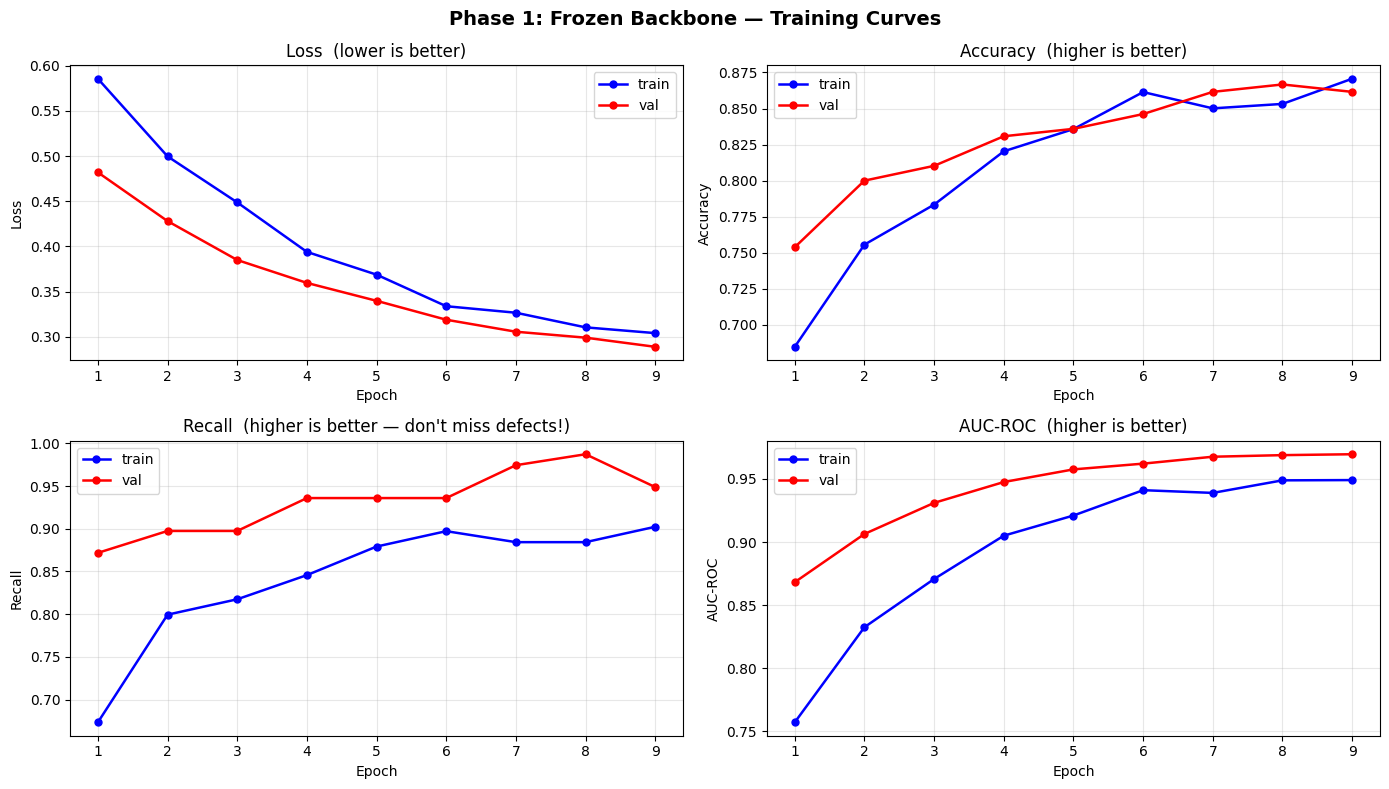

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 13: Plot training curves
# ─────────────────────────────────────────────────────────────────────────

def plot_history(history, title="Training History", epoch_offset=0):
    """
    Plot loss / accuracy / recall / AUC for one training phase.

    epoch_offset : pass len(history_phase1.epoch) when plotting phase 2
                   so the x-axis continues from where phase 1 left off.
    """
    h      = history.history
    epochs = range(epoch_offset + 1, epoch_offset + len(h["loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    metrics = [
        ("loss",     "val_loss",     "Loss",     "lower is better"),
        ("accuracy", "val_accuracy", "Accuracy", "higher is better"),
        ("recall",   "val_recall",   "Recall",   "higher is better — don't miss defects!"),
        ("auc",      "val_auc",      "AUC-ROC",  "higher is better"),
    ]
    for ax, (tk, vk, ylabel, note) in zip(axes.flat, metrics):
        if tk in h:
            ax.plot(epochs, h[tk], "b-o", markersize=5, linewidth=1.8, label="train")
        if vk in h:
            ax.plot(epochs, h[vk], "r-o", markersize=5, linewidth=1.8, label="val")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel}  ({note})")
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()


def plot_combined_history(h1, h2, title="Full Training — Phase 1 + Phase 2"):
    """
    Stitch both phases into a single 4-panel plot with a vertical
    dashed line marking where fine-tuning began.
    """
    n1 = len(h1.history["loss"])
    n2 = len(h2.history["loss"])
    epochs1 = list(range(1,        n1 + 1))
    epochs2 = list(range(n1 + 1,   n1 + n2 + 1))

    metrics = [
        ("loss",     "val_loss",     "Loss",     "lower is better"),
        ("accuracy", "val_accuracy", "Accuracy", "higher is better"),
        ("recall",   "val_recall",   "Recall",   "higher is better"),
        ("auc",      "val_auc",      "AUC-ROC",  "higher is better"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, (tk, vk, ylabel, note) in zip(axes.flat, metrics):
        # Phase 1
        if tk in h1.history:
            ax.plot(epochs1, h1.history[tk], "b-o", markersize=4,
                    linewidth=1.8, label="train (Ph.1)")
        if vk in h1.history:
            ax.plot(epochs1, h1.history[vk], "r-o", markersize=4,
                    linewidth=1.8, label="val (Ph.1)")
        # Phase 2
        if tk in h2.history:
            ax.plot(epochs2, h2.history[tk], "b--s", markersize=4,
                    linewidth=1.8, label="train (Ph.2)")
        if vk in h2.history:
            ax.plot(epochs2, h2.history[vk], "r--s", markersize=4,
                    linewidth=1.8, label="val (Ph.2)")

        # Fine-tune boundary
        ax.axvline(x=n1 + 0.5, color="gray", linestyle=":", linewidth=1.5,
                   label="fine-tuning starts")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel}  ({note})")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()


plot_history(history_phase1, title="Phase 1: Frozen Backbone — Training Curves")


## 4. Fine-Tuning — Phase 2

Now we **unfreeze the top layers** of the MobileNetV2 backbone and continue training with a much lower learning rate.

**Why not unfreeze everything?**  
- Bottom layers learned generic features (edges, textures) — universally useful  
- Top layers learned high-level ImageNet features — we want to specialise those  
- Very low LR avoids "catastrophic forgetting" of the pretrained knowledge  

**Rule of thumb:** Unfreeze the last 30–40% of backbone layers.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 14: Fine-tuning — unfreeze top 40 layers of backbone
# ─────────────────────────────────────────────────────────────────────────

UNFREEZE_LAST_N = 40

base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

trainable_now = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters now: {trainable_now:,}")
print(f"(Unfroze last {UNFREEZE_LAST_N} backbone layers + head)")

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1,
    ),
]

# How many epochs phase 1 actually ran (may be < EPOCHS_PHASE1 if early-stopped)
n_phase1_actual = len(history_phase1.history["loss"])
phase2_end      = n_phase1_actual + EPOCHS_PHASE2

print("\n" + "=" * 60)
print(f"PHASE 2: Fine-tuning  (top {UNFREEZE_LAST_N} backbone layers UNFROZEN)")
print(f"         Epochs {n_phase1_actual + 1} → {phase2_end}  ({EPOCHS_PHASE2} epochs budget)")
print("=" * 60)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=phase2_end,          # final epoch number (not a count)
    initial_epoch=n_phase1_actual,
    class_weight=class_weight,
    callbacks=callbacks_phase2,
    verbose=1,
)

n2 = len(history_phase2.history["loss"])
print(f"\n Phase 2 complete — ran {n2}/{EPOCHS_PHASE2} epochs.")
print(f"   Total epochs trained : {n_phase1_actual + n2} / {TOTAL_EPOCHS}")


Trainable parameters now: 1,682,817
(Unfroze last 40 backbone layers + head)

PHASE 2: Fine-tuning  (top 40 backbone layers UNFROZEN)
         Epochs 10 → 20  (11 epochs budget)
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.6732 - auc: 0.8793 - loss: 1.0878 - precision: 0.9017 - recall: 0.1441 - val_accuracy: 0.8154 - val_auc: 0.9663 - val_loss: 0.3752 - val_precision: 0.6875 - val_recall: 0.9872 - learning_rate: 1.0000e-05
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8408 - auc: 0.9213 - loss: 0.5532 - precision: 0.9395 - recall: 0.6190 - val_accuracy: 0.7897 - val_auc: 0.9684 - val_loss: 0.4213 - val_precision: 0.6555 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8805 - auc: 0.9502 - loss: 0.3281 - precision: 0.8864 - recall: 0.7851 - val_accuracy: 0.8051 - val_auc: 0.9726 - val_loss: 0.4221 - val_precision: 0.6724 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 13/20
31

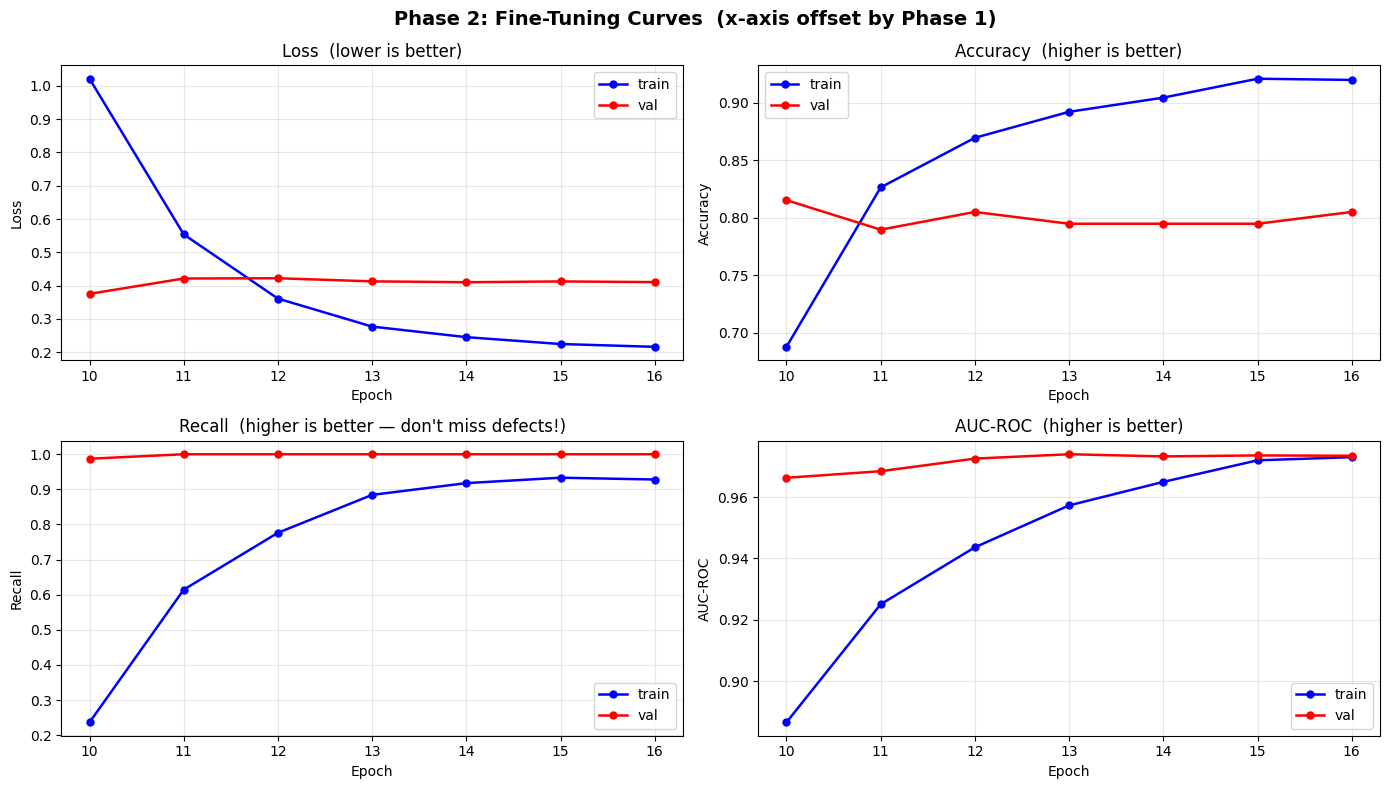

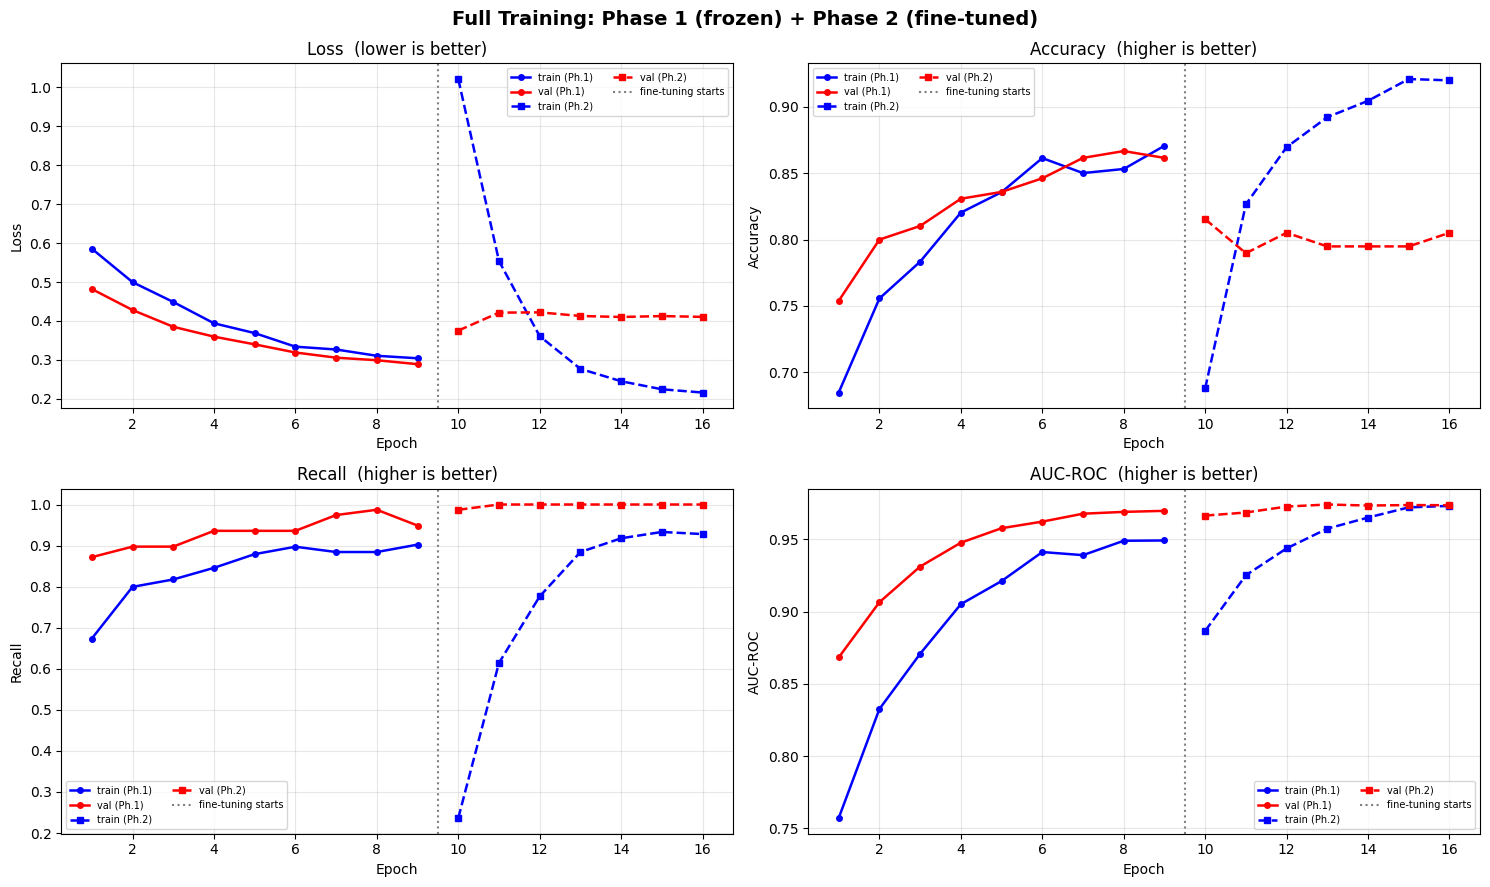


📊 Training summary:
  Phase 1 epochs    : 9
  Phase 2 epochs    : 7
  Total epochs run  : 16

  Phase 1 best val_loss : 0.2889
  Phase 2 best val_loss : 0.3752
  Phase 1 best val_auc  : 0.9696
  Phase 2 best val_auc  : 0.9740


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 15b: Plot Phase 2 curves + combined Phase 1 + Phase 2 view
# ─────────────────────────────────────────────────────────────────────────

# ── Phase 2 on its own (x-axis continues from phase 1) ────────────────
n_phase1_epochs = len(history_phase1.epoch)
plot_history(
    history_phase2,
    title="Phase 2: Fine-Tuning Curves  (x-axis offset by Phase 1)",
    epoch_offset=n_phase1_epochs,
)

# ── Both phases stitched together ─────────────────────────────────────
plot_combined_history(
    history_phase1, history_phase2,
    title="Full Training: Phase 1 (frozen) + Phase 2 (fine-tuned)"
)

# ── Handy summary table ───────────────────────────────────────────────
print("\n📊 Training summary:")
print(f"  Phase 1 epochs    : {n_phase1_epochs}")
print(f"  Phase 2 epochs    : {len(history_phase2.epoch)}")
print(f"  Total epochs run  : {n_phase1_epochs + len(history_phase2.epoch)}")
print()
print(f"  Phase 1 best val_loss : {min(history_phase1.history['val_loss']):.4f}")
print(f"  Phase 2 best val_loss : {min(history_phase2.history['val_loss']):.4f}")
print(f"  Phase 1 best val_auc  : {max(history_phase1.history['val_auc']):.4f}")
print(f"  Phase 2 best val_auc  : {max(history_phase2.history['val_auc']):.4f}")


## 5. Evaluation on the Test Set

### Metrics that matter in industry

| Metric | Formula | Why it matters |
|---|---|---|
| **Accuracy** | (TP+TN)/Total | Easy to report, but misleading with imbalanced data |
| **Precision** | TP/(TP+FP) | Of all flagged defectives, how many are real? → False alarm rate |
| **Recall** | TP/(TP+FN) | Of all real defectives, how many did we catch? → Miss rate |
| **F1 Score** | 2·P·R/(P+R) | Harmonic mean — balance of precision and recall |
| **AUC-ROC** | Area under ROC | Threshold-independent; 1.0 = perfect, 0.5 = random |

**In defect detection, Recall is usually the primary metric.**  
Missing a defective part (FN) is typically worse than a false alarm (FP).

### Confusion Matrix
```
                   Predicted
               defective  |  good
              ─────────────────────
Actual  defective |  TP    |   FN   |
        good      |  FP    |   TN   |
```
- **FN (False Negative):** defective part passed inspection → biggest risk  
- **FP (False Positive):** good part rejected → causes production delays


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 15: Evaluate on the held-out test set
# ─────────────────────────────────────────────────────────────────────────

results = model.evaluate(test_ds, verbose=0)
metric_names = model.metrics_names

print("=" * 45)
print("TEST SET RESULTS")
print("=" * 45)
for name, value in zip(metric_names, results):
    print(f"  {name:<15}: {value:.4f}")
print("=" * 45)


TEST SET RESULTS
  loss           : 0.3738
  compile_metrics: 0.8473


Classification Report (threshold=0.5):

              precision    recall  f1-score   support

   defective     0.9836    0.7595    0.8571        79
        good     0.7286    0.9808    0.8361        52

    accuracy                         0.8473       131
   macro avg     0.8561    0.8701    0.8466       131
weighted avg     0.8824    0.8473    0.8488       131



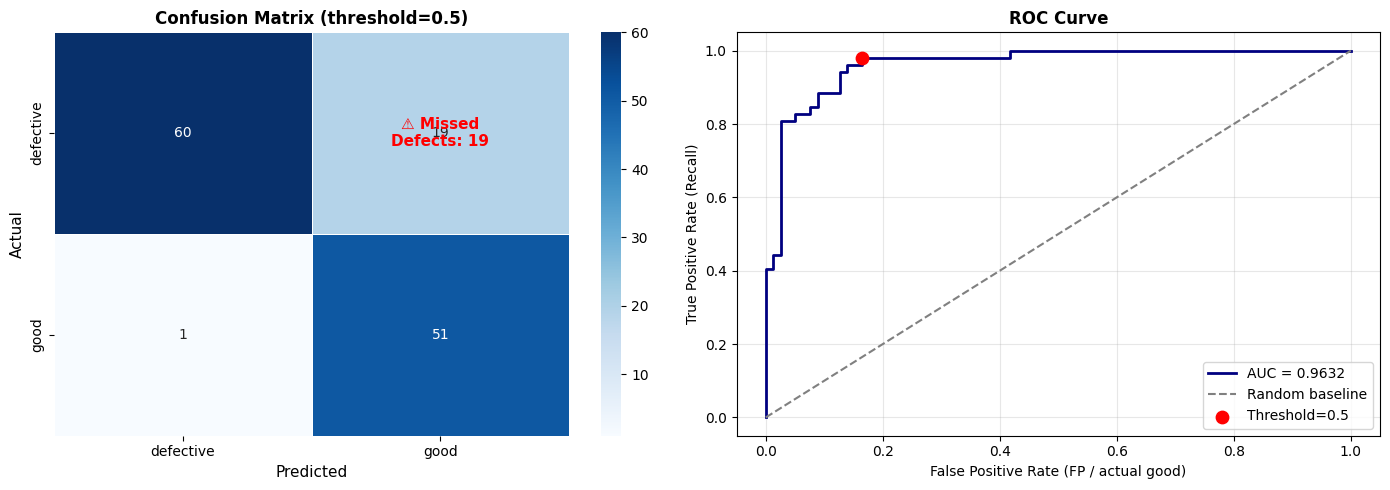


AUC-ROC: 0.9632
Missed defects (FN) at threshold 0.5: 19
→ Lowering threshold reduces missed defects but increases false alarms.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 16: Confusion matrix, classification report, ROC curve
# ─────────────────────────────────────────────────────────────────────────

# Collect ground-truth labels and predicted probabilities
y_true = np.concatenate([labels.numpy() for _, labels in test_ds]).astype(int)
y_prob = model.predict(test_ds, verbose=0).ravel()   # P(good)

# Default threshold: 0.5
# For higher recall, try a lower threshold (e.g. 0.3)
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

# ─── Classification report ───────────────────────────────────────────
print(f"Classification Report (threshold={THRESHOLD}):\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ─── Confusion Matrix ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5,
)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].set_title(f"Confusion Matrix (threshold={THRESHOLD})", fontsize=12, fontweight="bold")

# Annotate FN (missed defects) — cell [0,1] when rows=actual
fn = cm[0, 1]   # actual=defective (0), predicted=good (1)
axes[0].text(1.5, 0.5, f"⚠ Missed\nDefects: {fn}",
             ha="center", va="center", color="red", fontsize=11, fontweight="bold")

# ─── ROC Curve ────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

axes[1].plot(fpr, tpr, color="navy", lw=2, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random baseline")
axes[1].scatter(
    [fpr[np.argmin(np.abs(thresholds - THRESHOLD))]],
    [tpr[np.argmin(np.abs(thresholds - THRESHOLD))]],
    color="red", s=80, zorder=5, label=f"Threshold={THRESHOLD}"
)
axes[1].set_xlabel("False Positive Rate (FP / actual good)")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAUC-ROC: {auc_score:.4f}")
print(f"Missed defects (FN) at threshold {THRESHOLD}: {fn}")
print("→ Lowering threshold reduces missed defects but increases false alarms.")


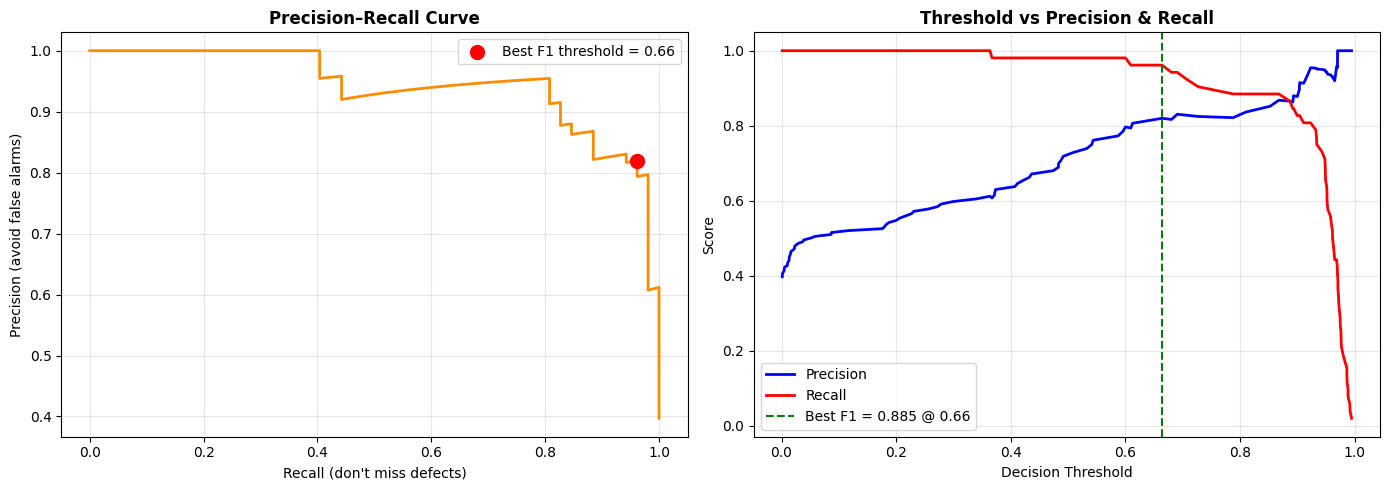

Best F1 threshold : 0.664
  Precision at best F1 : 0.8197
  Recall    at best F1 : 0.9615
  F1 score             : 0.8850


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 17: Threshold analysis — find optimal threshold for high recall
#
# In industry, you rarely use threshold=0.5.
# You tune it based on business requirements:
#   - "Never miss more than 2% of defects" → find threshold that achieves recall=0.98
# ─────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_prob)

# F1 at each threshold
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls, precisions, color="darkorange", lw=2)
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color="red", s=100, zorder=5,
                label=f"Best F1 threshold = {best_threshold:.2f}")
axes[0].set_xlabel("Recall (don't miss defects)")
axes[0].set_ylabel("Precision (avoid false alarms)")
axes[0].set_title("Precision–Recall Curve", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Threshold vs Precision/Recall
axes[1].plot(pr_thresholds, precisions[:-1], "b-", lw=2, label="Precision")
axes[1].plot(pr_thresholds, recalls[:-1],    "r-", lw=2, label="Recall")
axes[1].axvline(best_threshold, color="green", linestyle="--",
                label=f"Best F1 = {f1_scores[best_idx]:.3f} @ {best_threshold:.2f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Threshold vs Precision & Recall", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 threshold : {best_threshold:.3f}")
print(f"  Precision at best F1 : {precisions[best_idx]:.4f}")
print(f"  Recall    at best F1 : {recalls[best_idx]:.4f}")
print(f"  F1 score             : {f1_scores[best_idx]:.4f}")


## 6. Explainability with Grad-CAM

### What is Grad-CAM?
**Gradient-weighted Class Activation Mapping** highlights which pixels of an image caused the model's decision.

### How it works (simplified)
1. Pick the last convolutional feature maps — for MobileNetV2  
2. Compute gradient of the class score w.r.t. each feature map channel  
3. Average the gradients → importance weight per channel  
4. Weighted sum of feature maps → a coarse heatmap  
5. Upsample back to original image size and overlay

### Why this matters in industry
- Quality engineers can **verify** the model is looking at the actual defect  
- Helps catch shortcuts (e.g., model learned to recognise watermarks instead of defects)  
- Required for **regulated industries** (medical, aerospace, automotive)  
- Easier to communicate than raw probabilities

> 🔴 Red areas = high importance for the predicted class  
> 🔵 Blue areas = low importance


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 18: Grad-CAM implementation
# ─────────────────────────────────────────────────────────────────────────

def make_gradcam_heatmap(img_array, gradcam_model, class_idx=None):
    """
    Compute Grad-CAM heatmap.
    img_array   : (1,H,W,3) float32 raw pixels [0,255]
    class_idx   : 0=defective, 1=good, None=predicted class
    Returns     : heatmap (H,W) in [0,1],  pred_prob (P(good))
    """
    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(img_array, training=False)
        tape.watch(conv_outputs)
        pred_prob = float(predictions[0, 0])
        if class_idx is None:
            class_score = predictions[:,0] if pred_prob >= 0.5 else 1.0 - predictions[:,0]
        elif class_idx == 1:
            class_score = predictions[:,0]
        else:
            class_score = 1.0 - predictions[:,0]

    grads        = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    mx           = tf.math.reduce_max(heatmap)
    heatmap      = heatmap / mx if mx > 0 else heatmap
    return heatmap.numpy(), pred_prob


def overlay_gradcam(img_array, heatmap, alpha=0.45, cmap="jet"):
    """Return (original_rgb, heatmap_rgb, overlay_rgb).
    Compatible with matplotlib >= 3.7 (cm.get_cmap removed).
    """
    h_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()

    # matplotlib.colormaps works in mpl >= 3.5; falls back to plt.get_cmap for older
    try:
        colormap = plt.colormaps[cmap]
    except AttributeError:
        colormap = plt.get_cmap(cmap)

    heatmap_c  = (colormap(h_resized)[:, :, :3] * 255).astype(np.uint8)
    img_rgb    = img_array[0].numpy().astype(np.uint8)
    if img_rgb.shape[-1] == 1:
        img_rgb = np.repeat(img_rgb, 3, axis=-1)
    overlay = (img_rgb * (1 - alpha) + heatmap_c * alpha).astype(np.uint8)
    return img_rgb, heatmap_c, overlay


print(" Grad-CAM functions defined.")


 Grad-CAM functions defined.


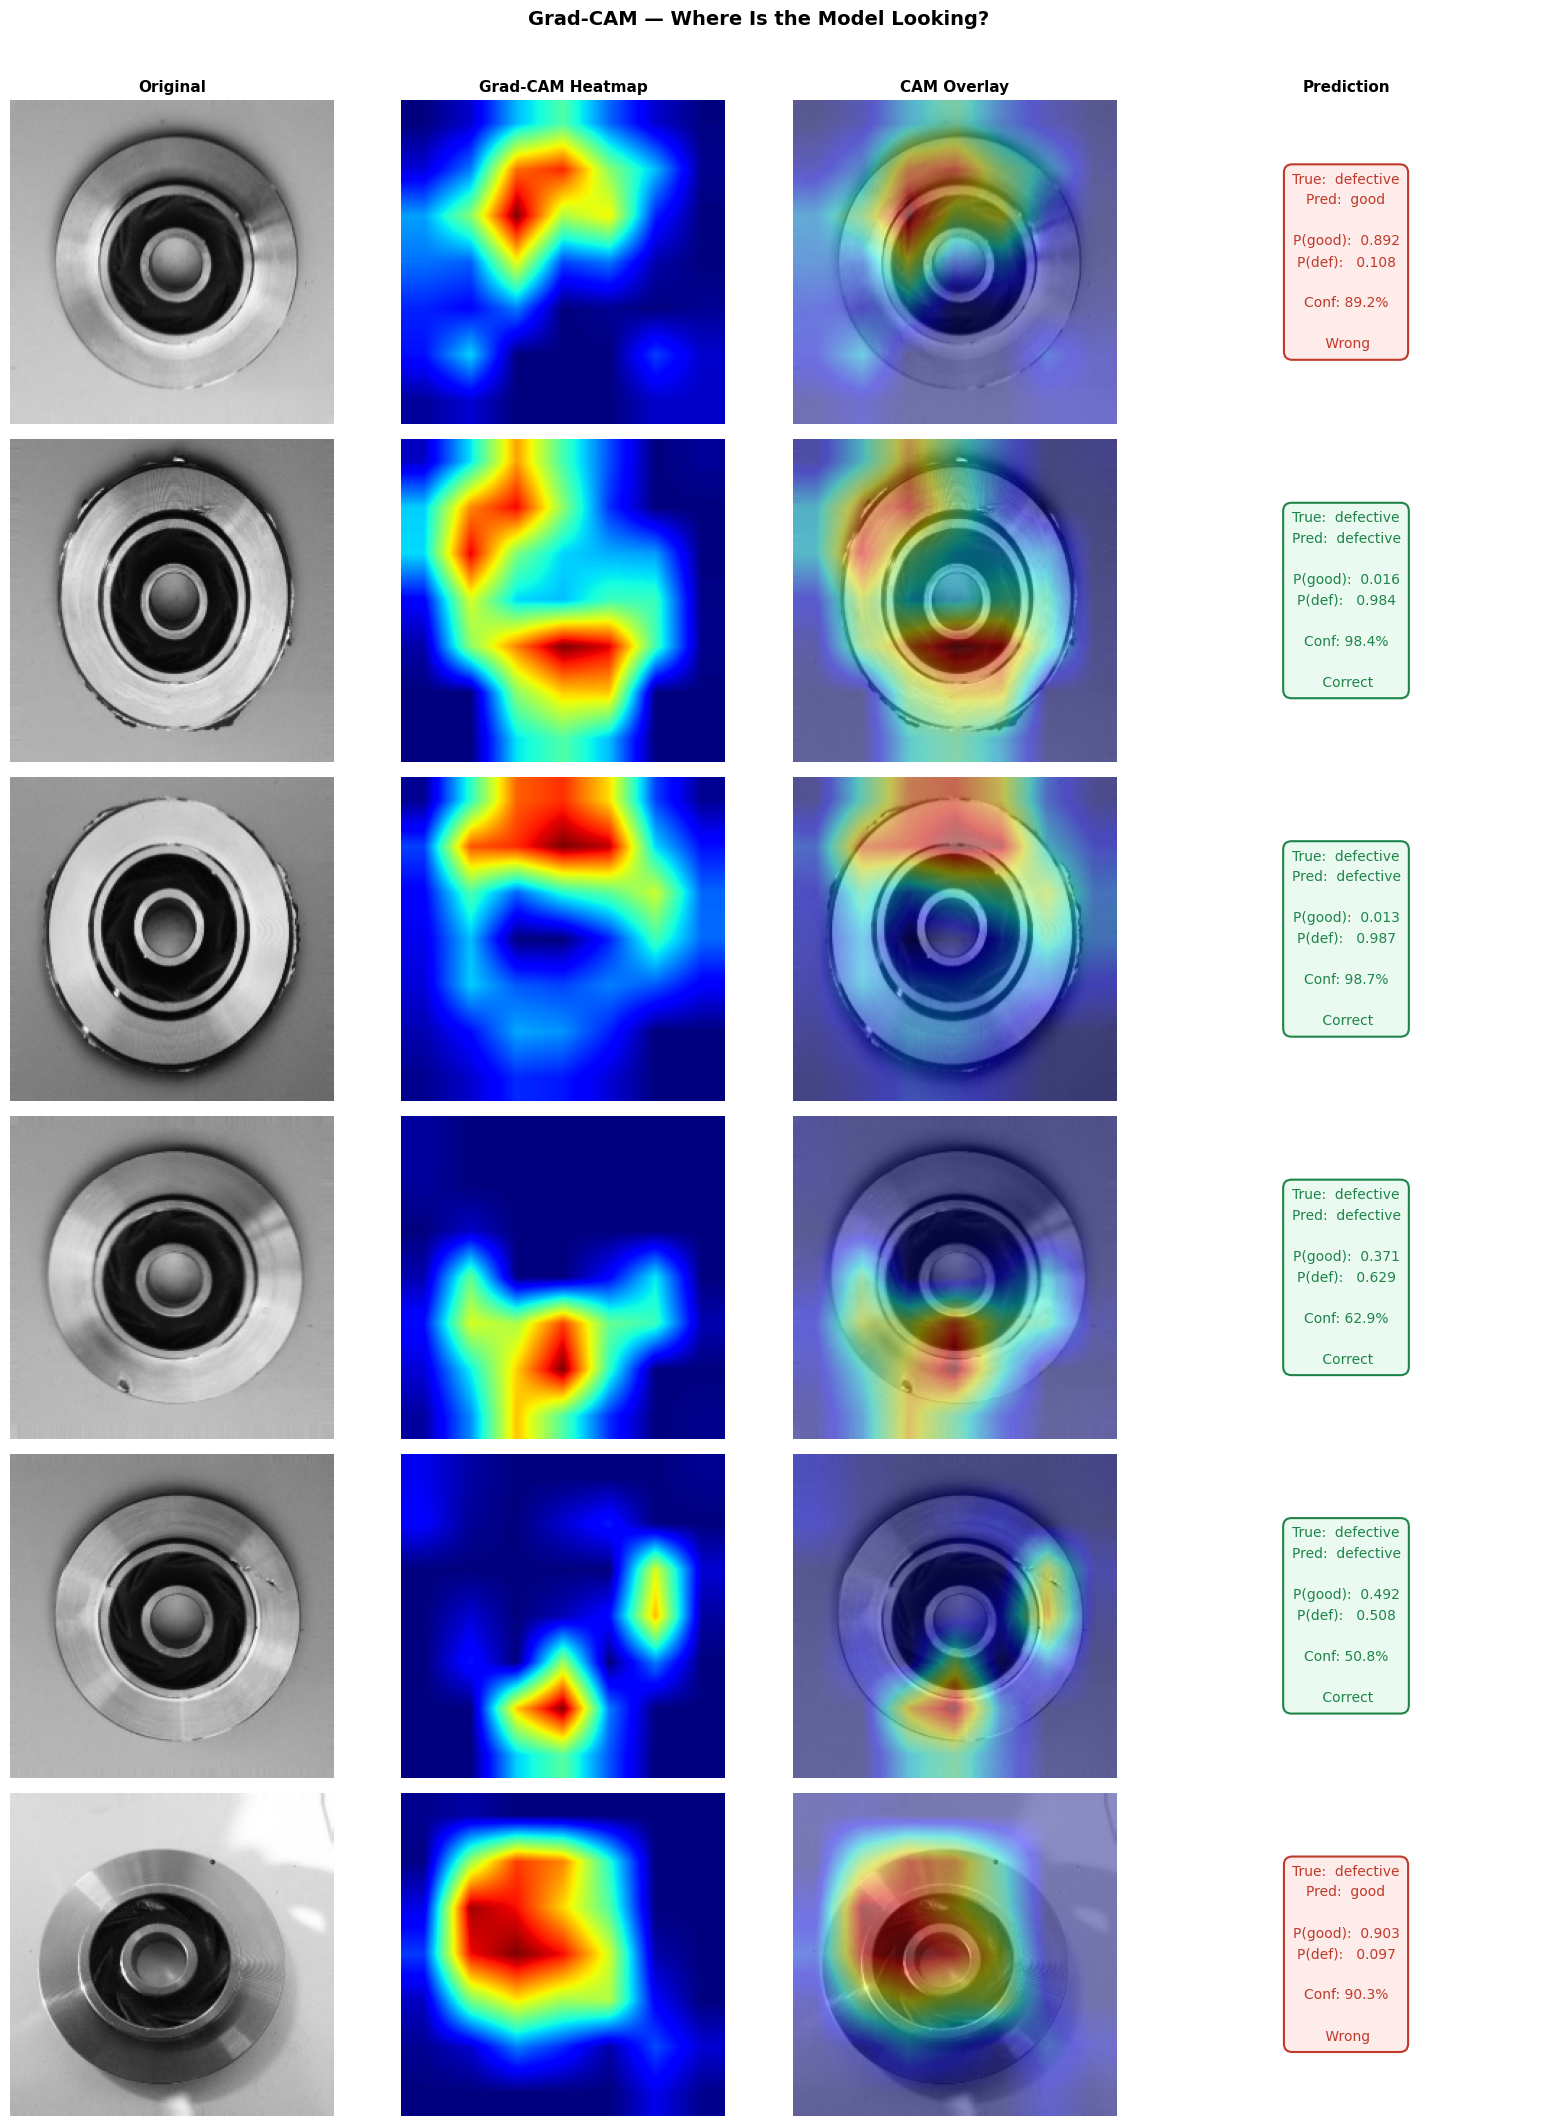

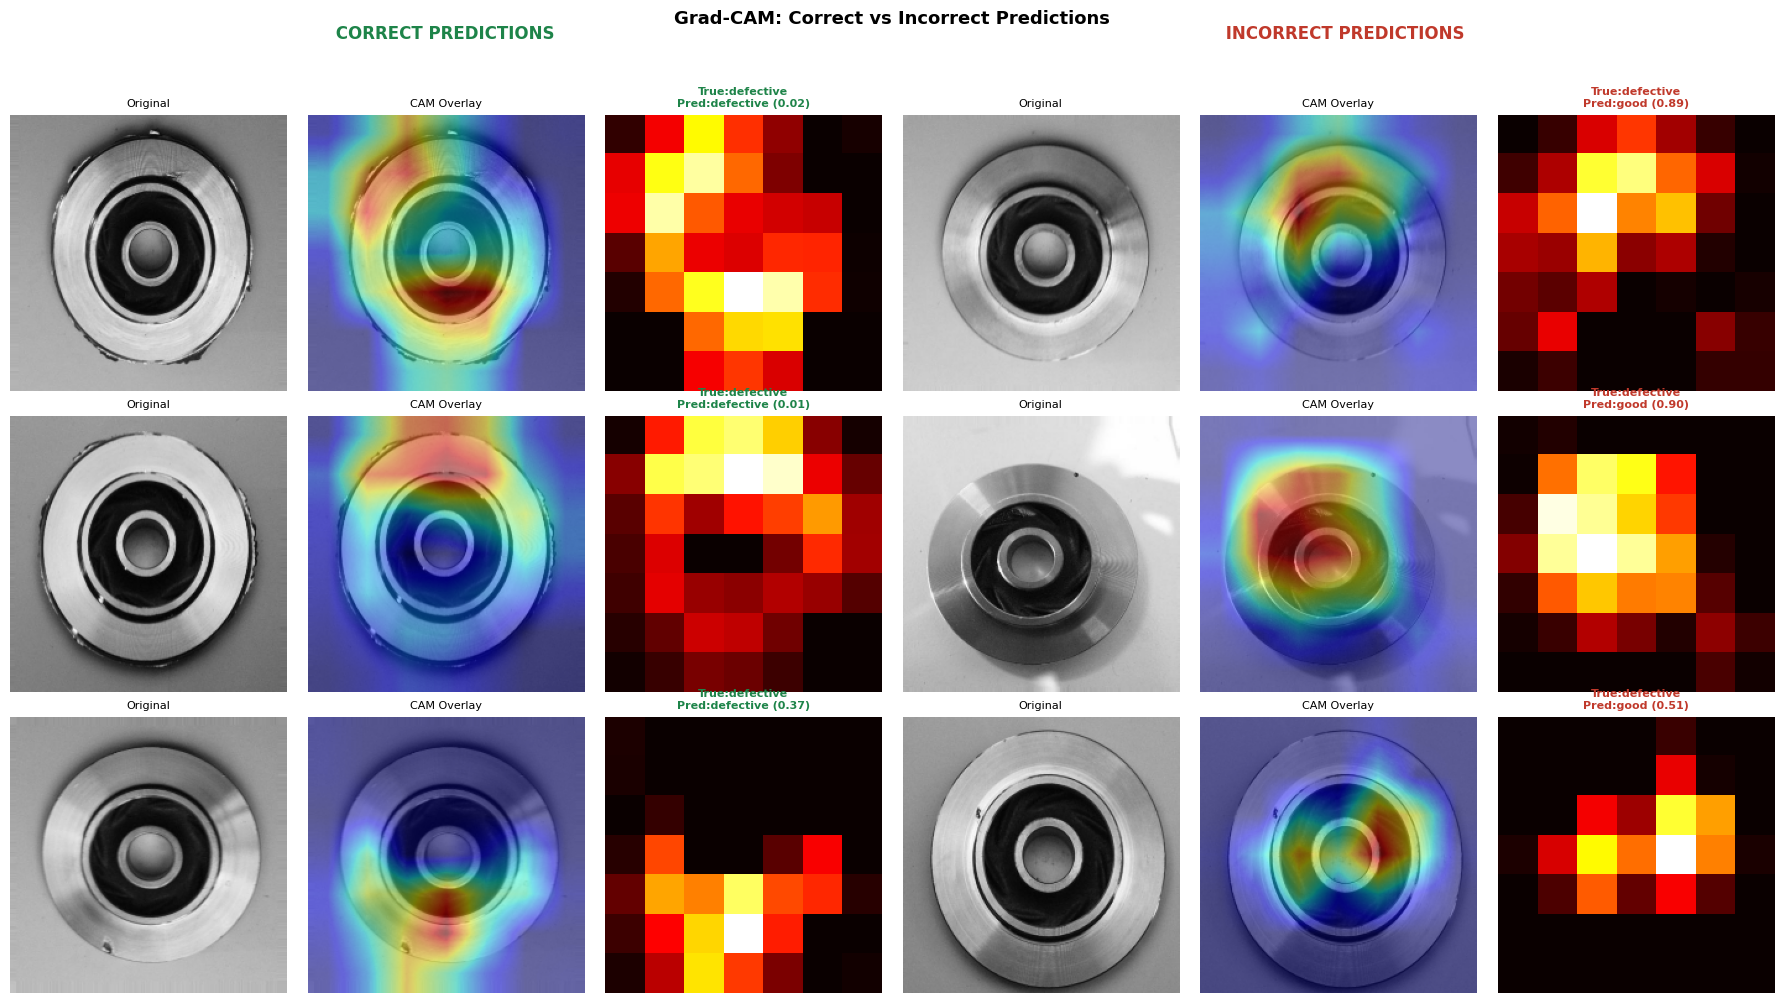

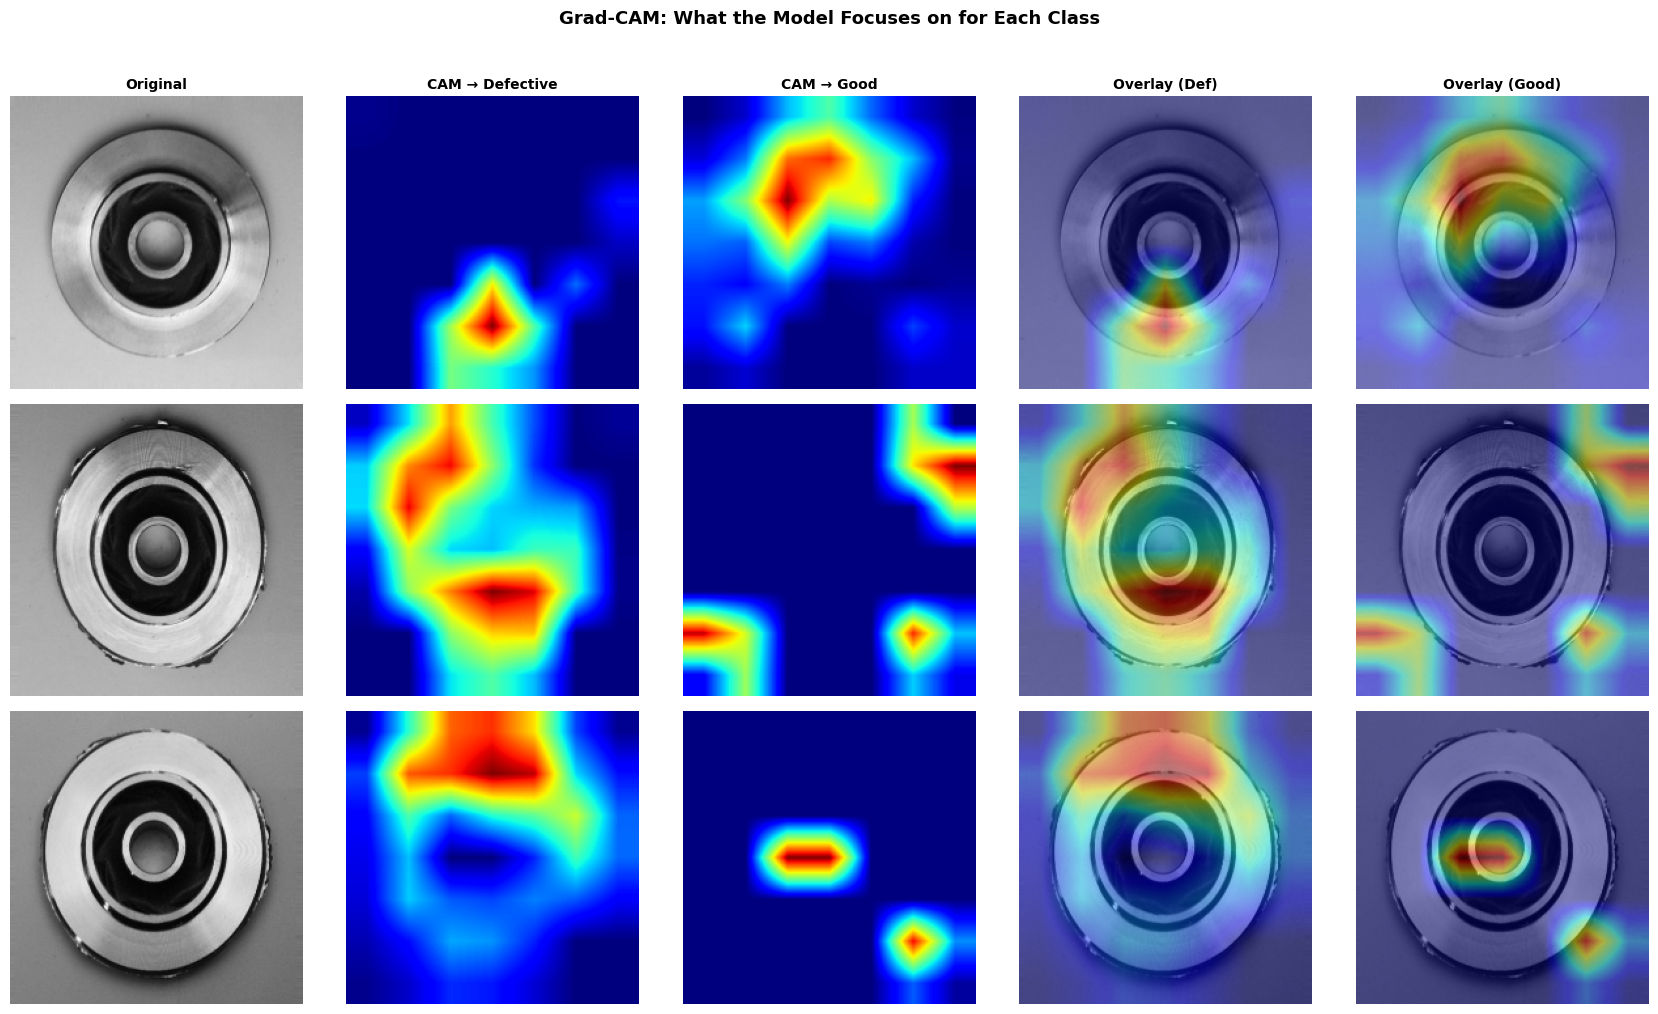


Interpretation:
   Red/warm  = regions most influential for that class decision
   Blue/cool = regions with little influence
   Defective-class maps should highlight the actual defect areas.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 19a: Grad-CAM — 4-column grid (Original | Heatmap | Overlay | Info)
# ─────────────────────────────────────────────────────────────────────────

N_SHOW = 6
fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 3.5))
for ax, t in zip(axes[0], ["Original", "Grad-CAM Heatmap", "CAM Overlay", "Prediction"]):
    ax.set_title(t, fontsize=11, fontweight="bold")

count = 0
for batch_images, batch_labels in test_ds:
    for img_tensor, true_label in zip(batch_images, batch_labels):
        if count >= N_SHOW: break
        img_arr   = tf.expand_dims(img_tensor, 0)
        true_name = CLASS_NAMES[int(true_label)]
        hm, pp    = make_gradcam_heatmap(img_arr, gradcam_model)
        pred_name = CLASS_NAMES[int(pp >= THRESHOLD)]
        img_rgb, hm_c, overlay = overlay_gradcam(img_arr, hm)

        axes[count,0].imshow(img_rgb, cmap="gray"); axes[count,0].axis("off")
        axes[count,1].imshow(hm_c);                 axes[count,1].axis("off")
        axes[count,2].imshow(overlay);              axes[count,2].axis("off")

        correct = pred_name == true_name
        bg  = "#eafaf1" if correct else "#fdecea"
        clr = "#1e8449" if correct else "#c0392b"
        conf = pp if pred_name == "good" else 1-pp
        info = (f"True:  {true_name}\nPred:  {pred_name}\n\n"
                f"P(good):  {pp:.3f}\nP(def):   {1-pp:.3f}\n\n"
                f"Conf: {conf:.1%}\n\n"
                f"{' Correct' if correct else ' Wrong'}")
        axes[count,3].text(0.5, 0.5, info, ha="center", va="center",
                           fontsize=10, color=clr, transform=axes[count,3].transAxes,
                           linespacing=1.6,
                           bbox=dict(boxstyle="round,pad=0.6", facecolor=bg,
                                     edgecolor=clr, linewidth=1.5))
        axes[count,3].axis("off")
        count += 1
    if count >= N_SHOW: break

plt.suptitle("Grad-CAM — Where Is the Model Looking?",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────────────────
# STEP 19b: Correct vs Incorrect prediction comparison
# ─────────────────────────────────────────────────────────────────────────

correct_ex, wrong_ex = [], []
MAX_EACH = 3

for batch_images, batch_labels in test_ds:
    for img_tensor, true_label in zip(batch_images, batch_labels):
        if len(correct_ex) >= MAX_EACH and len(wrong_ex) >= MAX_EACH: break
        img_arr   = tf.expand_dims(img_tensor, 0)
        true_name = CLASS_NAMES[int(true_label)]
        hm, pp    = make_gradcam_heatmap(img_arr, gradcam_model)
        pred_name = CLASS_NAMES[int(pp >= THRESHOLD)]
        img_rgb, _, overlay = overlay_gradcam(img_arr, hm)
        entry = (img_rgb, overlay, hm, true_name, pred_name, pp)
        if pred_name == true_name and len(correct_ex) < MAX_EACH:
            correct_ex.append(entry)
        elif pred_name != true_name and len(wrong_ex) < MAX_EACH:
            wrong_ex.append(entry)
    if len(correct_ex) >= MAX_EACH and len(wrong_ex) >= MAX_EACH: break

n_rows = max(len(correct_ex), len(wrong_ex))
if n_rows > 0:
    fig, axes = plt.subplots(n_rows, 6, figsize=(18, n_rows * 3.2))
    if n_rows == 1: axes = axes[np.newaxis, :]
    fig.text(0.25, 1.01, " CORRECT PREDICTIONS",  ha="center", fontsize=12,
             fontweight="bold", color="#1e8449")
    fig.text(0.75, 1.01, " INCORRECT PREDICTIONS", ha="center", fontsize=12,
             fontweight="bold", color="#c0392b")

    for c_start, examples in [(0, correct_ex), (3, wrong_ex)]:
        for row, (img_rgb, overlay, hm, tn, pn, pp) in enumerate(examples):
            clr = "#1e8449" if tn==pn else "#c0392b"
            axes[row, c_start].imshow(img_rgb, cmap="gray"); axes[row,c_start].axis("off")
            axes[row, c_start].set_title("Original", fontsize=8)
            axes[row, c_start+1].imshow(overlay);           axes[row,c_start+1].axis("off")
            axes[row, c_start+1].set_title("CAM Overlay", fontsize=8)
            axes[row, c_start+2].imshow(hm, cmap="hot", vmin=0, vmax=1)
            axes[row, c_start+2].set_title(f"True:{tn}\nPred:{pn} ({pp:.2f})",
                                            fontsize=8, color=clr, fontweight="bold")
            axes[row, c_start+2].axis("off")

    plt.suptitle("Grad-CAM: Correct vs Incorrect Predictions",
                 fontsize=13, fontweight="bold", y=1.04)
    plt.tight_layout(); plt.show()
else:
    print("ℹ  Not enough examples to plot comparison (need both correct and incorrect).")

# ─────────────────────────────────────────────────────────────────────────
# STEP 19c: Dual-class attention — defective focus vs good focus
# ─────────────────────────────────────────────────────────────────────────

N_CMP = 3
fig, axes = plt.subplots(N_CMP, 5, figsize=(17, N_CMP * 3.3))
for ax, t in zip(axes[0], ["Original", "CAM → Defective", "CAM → Good",
                             "Overlay (Def)", "Overlay (Good)"]):
    ax.set_title(t, fontsize=10, fontweight="bold")

count = 0
for batch_images, batch_labels in test_ds:
    for img_tensor, true_label in zip(batch_images, batch_labels):
        if count >= N_CMP: break
        img_arr   = tf.expand_dims(img_tensor, 0)
        hm_def, pp = make_gradcam_heatmap(img_arr, gradcam_model, class_idx=0)
        hm_good, _ = make_gradcam_heatmap(img_arr, gradcam_model, class_idx=1)
        img_rgb, hmc_def,  ov_def  = overlay_gradcam(img_arr, hm_def)
        _,       hmc_good, ov_good = overlay_gradcam(img_arr, hm_good)
        true_name = CLASS_NAMES[int(true_label)]
        pred_name = CLASS_NAMES[int(pp >= THRESHOLD)]

        axes[count,0].imshow(img_rgb, cmap="gray"); axes[count,0].axis("off")
        axes[count,0].set_xlabel(
            f"True: {true_name}  |  Pred: {pred_name}  (P(good)={pp:.3f})",
            fontsize=8, color="#1e8449" if true_name==pred_name else "#c0392b")
        axes[count,1].imshow(hmc_def);  axes[count,1].axis("off")
        axes[count,2].imshow(hmc_good); axes[count,2].axis("off")
        axes[count,3].imshow(ov_def);   axes[count,3].axis("off")
        axes[count,4].imshow(ov_good);  axes[count,4].axis("off")
        count += 1
    if count >= N_CMP: break

plt.suptitle("Grad-CAM: What the Model Focuses on for Each Class",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("\nInterpretation:")
print("   Red/warm  = regions most influential for that class decision")
print("   Blue/cool = regions with little influence")
print("   Defective-class maps should highlight the actual defect areas.")


## 7. Production Considerations

This notebook demonstrates the core ML pipeline. A full production system requires additional engineering.

### Data concerns
| Issue | Why it matters | Mitigation |
|---|---|---|
| Class imbalance | More defectives than good → biased model | Class weights, oversampling |
| Label quality | Wrong annotations corrupt training | Double annotation, review dashboard |
| Domain shift | New factory line, different camera | Retrain / adapt on new domain |
| Lighting changes | Morning vs evening production | Augmentation + lighting normalisation |

### Model concerns
| Issue | Why it matters | Mitigation |
|---|---|---|
| Threshold = 0.5 | Rarely optimal | Tune on business KPIs (recall ≥ 98%) |
| New defect types | Model has never seen them | Active learning, periodic retraining |
| Confidence calibration | Sigmoid ≠ true probability | Platt scaling, temperature scaling |

### System concerns
| Requirement | Solution |
|---|---|
| Latency < 10ms | Export to TensorLite / ONNX for edge device |
| Monitor performance | Log predictions + outcomes, alert on drift |
| Human review loop | Flag low-confidence cases (0.4–0.6) for human review |
| Model versioning | MLflow / DVC / model registry |
| Audit trail | Store image + prediction + timestamp for traceability |

### Deployment sketch
```
Camera → Frame grab → Preprocess → MobileNetV2 (TFLite) → Decision
                                                          ↓
                                             P < 0.3 → REJECT (defective)
                                             P > 0.7 → ACCEPT (good)
                                             0.3–0.7 → HUMAN REVIEW queue
```


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 20: Save the model
# ─────────────────────────────────────────────────────────────────────────

# ── Native Keras format (recommended) ─────────────────────────────────
model.save("defect_detector_model.keras")
print(" Keras model saved: defect_detector_model.keras")
print("   Reload with: model = keras.models.load_model('defect_detector_model.keras')")

# ── Export TF SavedModel (needed for TFLite conversion) ───────────────
model.export("defect_detector_savedmodel")
print(" SavedModel exported: defect_detector_savedmodel/")

print()
print("Deployment formats:")
print("  defect_detector_model.keras   → standard Keras reload")
print("  defect_detector_savedmodel/   → TFServing")
print("  defect_detector.tflite        → Raspberry Pi / Android / iOS")

 Keras model saved: defect_detector_model.keras
   Reload with: model = keras.models.load_model('defect_detector_model.keras')
Saved artifact at 'defect_detector_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134942677630800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676202896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676197328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676203664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676190992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676194064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676196560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134942676195216: T

## 8. Extensions for Further Practice

| # | Task | Skill area |
|---|---|---|
| 1 | Replace MobileNetV2 with **EfficientNetV2S** and compare results | Model selection |
| 2 | Try **multi-class** defect detection (pit / blowhole / scratch as separate classes) | Classification |
| 3 | Implement **anomaly detection** — train only on good parts, flag outliers | Unsupervised ML |
| 4 | Apply **SHAP** (SHapley values) in addition to Grad-CAM | XAI |
| 5 | Use **Albumentations** library for more realistic industrial augmentations | Data engineering |
| 6 | Build a simple **FastAPI** endpoint that accepts an image and returns a prediction | MLOps |
| 7 | Quantise the TFLite model and measure latency on CPU | Deployment |
| 8 | Implement a **rejection threshold** (three-region decision) and measure human review load | Business logic |

---

## Summary

This notebook demonstrated a **complete, runnable, industry-oriented defect detection pipeline**:

- ✅ Real dataset (Casting Product, Kaggle)  
- ✅ Transfer learning with MobileNetV2  
- ✅ Class imbalance handling  
- ✅ Evaluation beyond accuracy (Recall, AUC, PR curve)  
- ✅ Threshold analysis for production tuning  
- ✅ Grad-CAM explainability  
- ✅ Two-phase training (frozen → fine-tune)  
- ✅ TFLite export for edge deployment  
